In [1]:
import os
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import yaml

from mejiro.utils import util

# read configuration file
config_file = os.path.join(os.path.expanduser('~'), 'mejiro', 'mejiro', 'data', 'mejiro_config', 'roman_data_challenge_rung_1_unlabeled.yaml')
with open(config_file, 'r') as f:
    config = yaml.load(f, Loader=yaml.SafeLoader)

if config['dev']:
    config['pipeline_label'] += '_dev'

data_dir = os.path.join(config['data_dir'], config['pipeline_label'], '01b')
print(f'Data directory: {data_dir}')

Data directory: /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1_unlabeled/01b


In [2]:
# load all detectable gglens pickle files
pkl_paths = sorted(glob(os.path.join(data_dir, 'detectable_gglenses_*.pkl')))
print(f'Found {len(pkl_paths)} pickle file(s)')

all_lenses = []
file_counts = []
for path in pkl_paths:
    lenses = util.unpickle(path)
    file_counts.append((os.path.basename(path), len(lenses)))
    all_lenses.extend(lenses)

print(f'Total detectable lenses: {len(all_lenses)}')
print(f'\nLenses per run:')
for name, count in file_counts:
    print(f'  {name}: {count}')

Found 32 pickle file(s)
Total detectable lenses: 420

Lenses per run:
  detectable_gglenses_0000_sca01.pkl: 13
  detectable_gglenses_0001_sca02.pkl: 9
  detectable_gglenses_0002_sca03.pkl: 12
  detectable_gglenses_0003_sca04.pkl: 8
  detectable_gglenses_0004_sca05.pkl: 9
  detectable_gglenses_0005_sca06.pkl: 12
  detectable_gglenses_0006_sca07.pkl: 16
  detectable_gglenses_0007_sca08.pkl: 15
  detectable_gglenses_0008_sca09.pkl: 21
  detectable_gglenses_0009_sca10.pkl: 8
  detectable_gglenses_0010_sca11.pkl: 11
  detectable_gglenses_0011_sca12.pkl: 9
  detectable_gglenses_0012_sca13.pkl: 13
  detectable_gglenses_0013_sca14.pkl: 18
  detectable_gglenses_0014_sca15.pkl: 20
  detectable_gglenses_0015_sca16.pkl: 14
  detectable_gglenses_0016_sca17.pkl: 12
  detectable_gglenses_0017_sca18.pkl: 15
  detectable_gglenses_0018_sca01.pkl: 13
  detectable_gglenses_0019_sca02.pkl: 7
  detectable_gglenses_0020_sca03.pkl: 12
  detectable_gglenses_0021_sca04.pkl: 14
  detectable_gglenses_0022_sca05.p

In [3]:
sample = all_lenses[0]

sample._source[0]._source.__dict__

{'name': 'GAL',
 '_z': 3.98775640716071,
 'lensed': True,
 '_model_type': 'SourceBase',
 '_point_source': False,
 '_extended_source': True,
 '_center_source': array([ 0.16144686, -0.23542502]),
 '_offset': array([0, 0]),
 'source_dict': {'z': np.float64(3.98775640716071),
  'M': np.float64(-23.018002619259548),
  'coeff': array([0.20321859, 0.00082938, 0.28427687, 0.49058051, 0.02109465]),
  'ellipticity': np.float64(0.05152943508544076),
  'physical_size': np.float64(3.1178520165763173),
  'stellar_mass': np.float64(197269978094.42426),
  'mag_F062': np.float64(24.5571625518457),
  'mag_F087': np.float64(24.416120094579256),
  'mag_F106': np.float64(24.28791937711363),
  'mag_F129': np.float64(24.263008022634054),
  'mag_F158': np.float64(24.01426386566378),
  'mag_F184': np.float64(23.615128263349618),
  'mag_F146': np.float64(24.037718971041507),
  'mag_F213': np.float64(23.082042969852772)},
 '_variability_bands': {},
 '_variability_model': 'NONE',
 '_kwargs_variability_model': {},

In [5]:
dict(sample._source[0]._source._matched_source)

{'id': np.int64(550104),
 'angular_size': np.float64(0.5670349218599274),
 'sersic_index': np.float64(1.968048651297565),
 'sersic_fit_chi2': np.float64(296.1020202636719),
 'sersic_angle': np.float64(0.8018682189042599),
 'axis_ratio': np.float64(0.9495389811522806),
 'z': np.float64(0.3741),
 'physical_size': np.float64(3.014995023798652)}

In [ ]:
# extract key properties from all lenses
z_deflector = []
z_source = []
einstein_radii = []
stellar_masses = []
velocity_dispersions = []
magnifications = []
image_numbers = []

for lens in all_lenses:
    z_deflector.append(lens.deflector_redshift)
    z_source.append(lens.source_redshift_list[0])
    einstein_radii.append(lens.einstein_radius[0])
    stellar_masses.append(lens.deflector_stellar_mass())
    velocity_dispersions.append(lens.deflector_velocity_dispersion())
    magnifications.append(lens.extended_source_magnification[0])
    image_numbers.append(lens.image_number[0])

z_deflector = np.array(z_deflector)
z_source = np.array(z_source)
einstein_radii = np.array(einstein_radii)
stellar_masses = np.array(stellar_masses)
velocity_dispersions = np.array(velocity_dispersions)
magnifications = np.array(magnifications)
image_numbers = np.array(image_numbers)

print(f'Properties extracted for {len(all_lenses)} lenses')

ERROR:2026-03-22 01:23:05,632:jax._src.xla_bridge:477: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/data/bwedig/.conda/envs/mejiro-v3/lib/python3.13/site-packages/jax/_src/xla_bridge.py", line 475, in discover_pjrt_plugins
    plugin_module.initialize()
    ~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/data/bwedig/.conda/envs/mejiro-v3/lib/python3.13/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
    ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/data/bwedig/.conda/envs/mejiro-v3/lib/python3.13/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA lib

Properties extracted for 896 lenses


In [ ]:
# summary statistics
area = config['survey']['area']
num_runs = len(pkl_paths)

print(f'Survey area per run: {area} deg^2')
print(f'Number of runs: {num_runs}')
print(f'Total detectable lenses: {len(all_lenses)}')
print(f'Detectable lenses per sq deg: {len(all_lenses) / area / num_runs:.2f}')
print(f'\n--- Deflector redshift ---')
print(f'  Mean: {z_deflector.mean():.3f}, Median: {np.median(z_deflector):.3f}, Range: [{z_deflector.min():.3f}, {z_deflector.max():.3f}]')
print(f'\n--- Source redshift ---')
print(f'  Mean: {z_source.mean():.3f}, Median: {np.median(z_source):.3f}, Range: [{z_source.min():.3f}, {z_source.max():.3f}]')
print(f'\n--- Einstein radius (arcsec) ---')
print(f'  Mean: {einstein_radii.mean():.3f}, Median: {np.median(einstein_radii):.3f}, Range: [{einstein_radii.min():.3f}, {einstein_radii.max():.3f}]')
print(f'\n--- Magnification ---')
print(f'  Mean: {magnifications.mean():.2f}, Median: {np.median(magnifications):.2f}, Range: [{magnifications.min():.2f}, {magnifications.max():.2f}]')
print(f'\n--- Velocity dispersion (km/s) ---')
print(f'  Mean: {velocity_dispersions.mean():.1f}, Median: {np.median(velocity_dispersions):.1f}, Range: [{velocity_dispersions.min():.1f}, {velocity_dispersions.max():.1f}]')
print(f'\n--- Image multiplicity ---')
for n in sorted(np.unique(image_numbers)):
    count = np.sum(image_numbers == n)
    print(f'  {n} images: {count} ({count / len(image_numbers) * 100:.1f}%)')

Survey area per run: 0.5 deg^2
Number of runs: 60
Total detectable lenses: 896
Detectable lenses per sq deg: 29.87

--- Deflector redshift ---
  Mean: 0.855, Median: 0.793, Range: [0.122, 2.557]

--- Source redshift ---
  Mean: 2.616, Median: 2.479, Range: [0.746, 7.463]

--- Einstein radius (arcsec) ---
  Mean: 0.806, Median: 0.664, Range: [0.166, 3.670]

--- Magnification ---
  Mean: 5.79, Median: 4.46, Range: [3.00, 48.79]

--- Velocity dispersion (km/s) ---
  Mean: 203.5, Median: 199.6, Range: [73.8, 421.8]

--- Image multiplicity ---
  2 images: 554 (61.8%)
  3 images: 205 (22.9%)
  4 images: 107 (11.9%)
  5 images: 30 (3.3%)


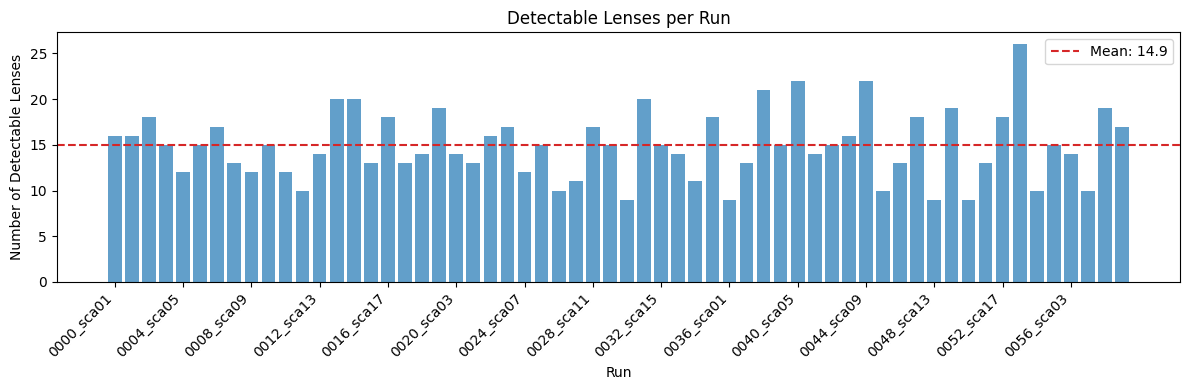

In [ ]:
# detectable lenses per run
fig, ax = plt.subplots(figsize=(12, 4))
run_labels = [name.replace('detectable_gglenses_', '').replace('.pkl', '') for name, _ in file_counts]
counts = [c for _, c in file_counts]
ax.bar(range(len(counts)), counts, color='C0', alpha=0.7)
ax.axhline(np.mean(counts), color='C3', linestyle='--', label=f'Mean: {np.mean(counts):.1f}')
ax.set_xlabel('Run')
ax.set_ylabel('Number of Detectable Lenses')
ax.set_title('Detectable Lenses per Run')
ax.set_xticks(range(0, len(counts), max(1, len(counts) // 15)))
ax.set_xticklabels([run_labels[i] for i in range(0, len(counts), max(1, len(counts) // 15))], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

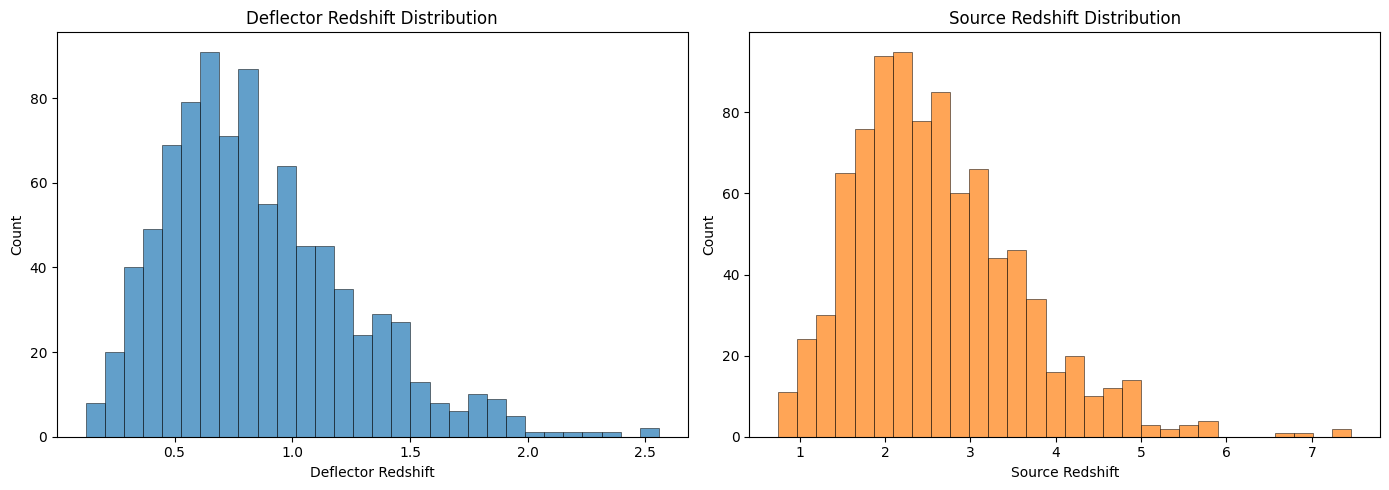

In [ ]:
# redshift distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(z_deflector, bins=30, alpha=0.7, color='C0', edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Deflector Redshift')
axes[0].set_ylabel('Count')
axes[0].set_title('Deflector Redshift Distribution')

axes[1].hist(z_source, bins=30, alpha=0.7, color='C1', edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Source Redshift')
axes[1].set_ylabel('Count')
axes[1].set_title('Source Redshift Distribution')

plt.tight_layout()
plt.show()

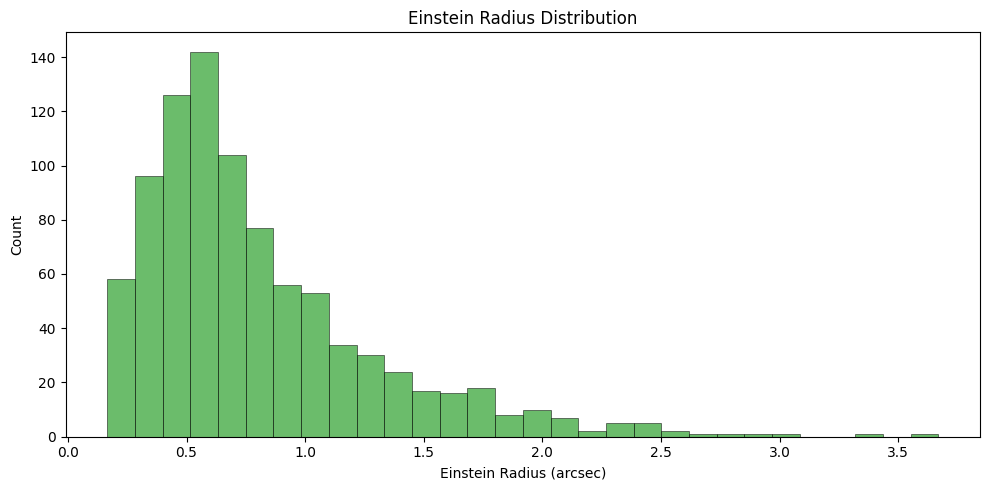

In [ ]:
# Einstein radius distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(einstein_radii, bins=30, alpha=0.7, color='C2', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Einstein Radius (arcsec)')
ax.set_ylabel('Count')
ax.set_title('Einstein Radius Distribution')
plt.tight_layout()
plt.show()

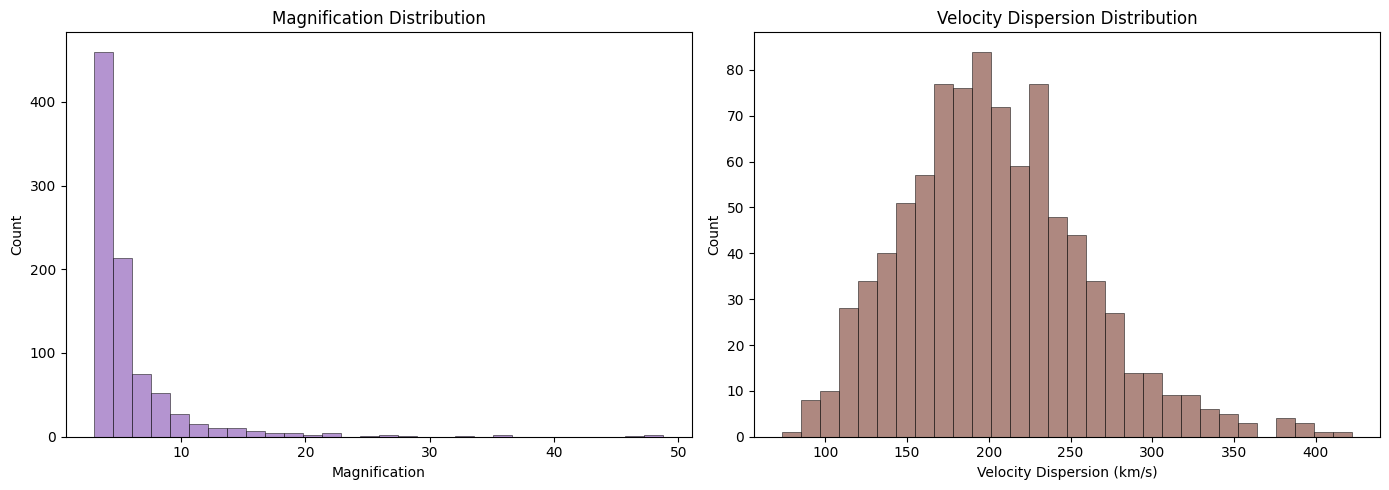

In [ ]:
# magnification and velocity dispersion distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(magnifications, bins=30, alpha=0.7, color='C4', edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Magnification')
axes[0].set_ylabel('Count')
axes[0].set_title('Magnification Distribution')

axes[1].hist(velocity_dispersions, bins=30, alpha=0.7, color='C5', edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Velocity Dispersion (km/s)')
axes[1].set_ylabel('Count')
axes[1].set_title('Velocity Dispersion Distribution')

plt.tight_layout()
plt.show()

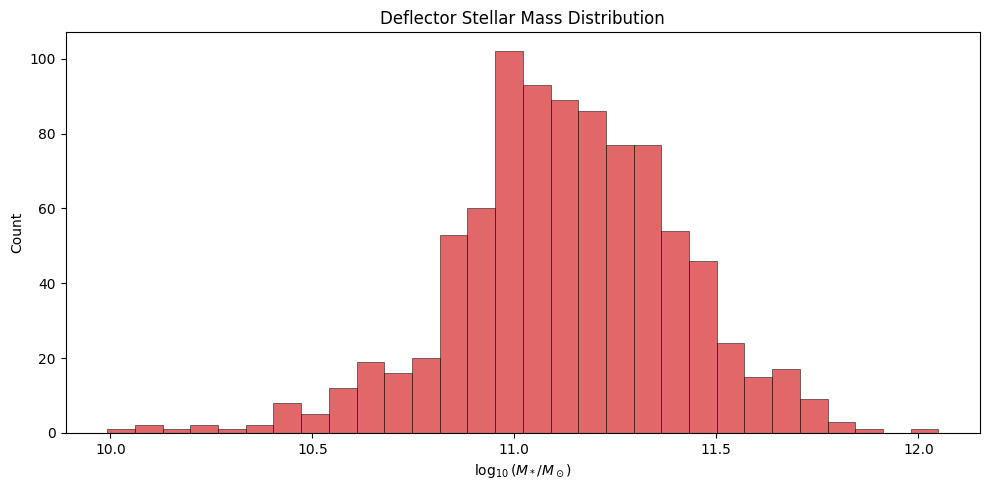

In [ ]:
# deflector stellar mass distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.log10(stellar_masses), bins=30, alpha=0.7, color='C3', edgecolor='black', linewidth=0.5)
ax.set_xlabel(r'$\log_{10}(M_*/M_\odot)$')
ax.set_ylabel('Count')
ax.set_title('Deflector Stellar Mass Distribution')
plt.tight_layout()
plt.show()

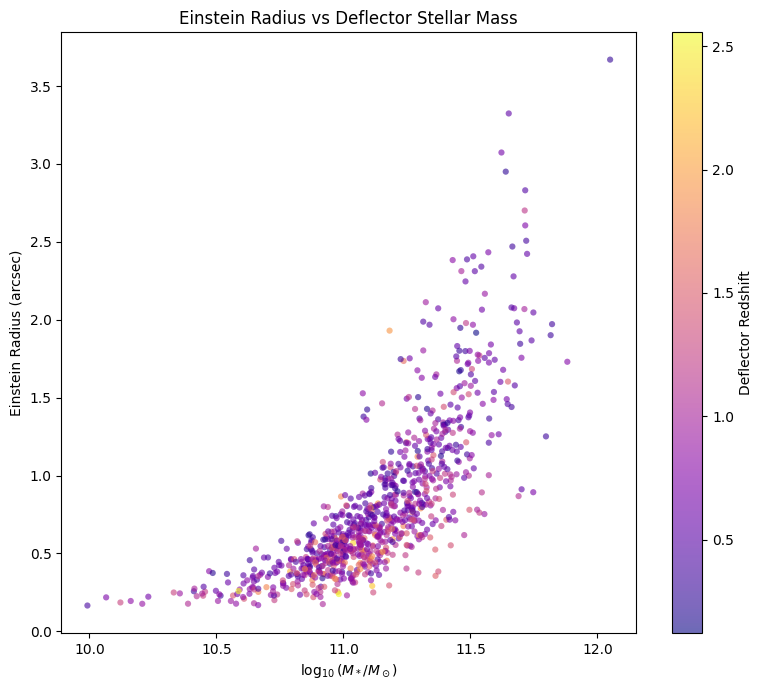

In [ ]:
# Einstein radius vs deflector stellar mass
fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(np.log10(stellar_masses), einstein_radii, c=z_deflector, cmap='plasma', alpha=0.6, s=20, edgecolors='none')
plt.colorbar(sc, ax=ax, label='Deflector Redshift')
ax.set_xlabel(r'$\log_{10}(M_*/M_\odot)$')
ax.set_ylabel('Einstein Radius (arcsec)')
ax.set_title('Einstein Radius vs Deflector Stellar Mass')
plt.tight_layout()
plt.show()

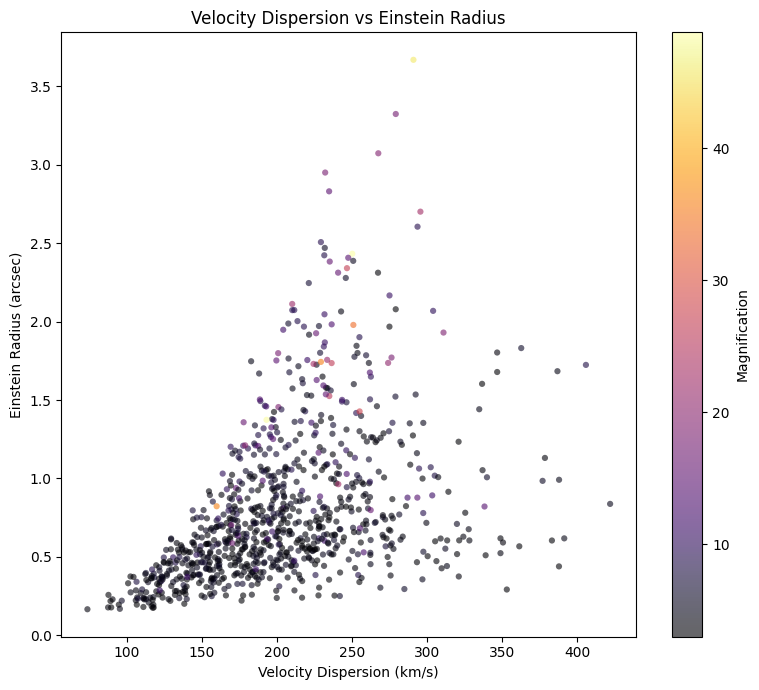

In [ ]:
# velocity dispersion vs Einstein radius
fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(velocity_dispersions, einstein_radii, c=magnifications, cmap='inferno', alpha=0.6, s=20, edgecolors='none')
plt.colorbar(sc, ax=ax, label='Magnification')
ax.set_xlabel('Velocity Dispersion (km/s)')
ax.set_ylabel('Einstein Radius (arcsec)')
ax.set_title('Velocity Dispersion vs Einstein Radius')
plt.tight_layout()
plt.show()

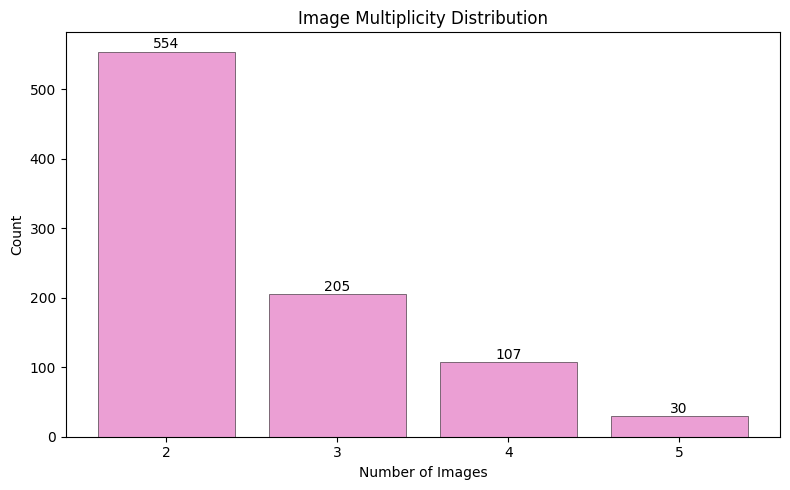

In [ ]:
# image multiplicity
fig, ax = plt.subplots(figsize=(8, 5))
unique, counts_mult = np.unique(image_numbers, return_counts=True)
ax.bar(unique, counts_mult, color='C6', alpha=0.7, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Number of Images')
ax.set_ylabel('Count')
ax.set_title('Image Multiplicity Distribution')
ax.set_xticks(unique)
for u, c in zip(unique, counts_mult):
    ax.text(u, c + 0.5, str(c), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

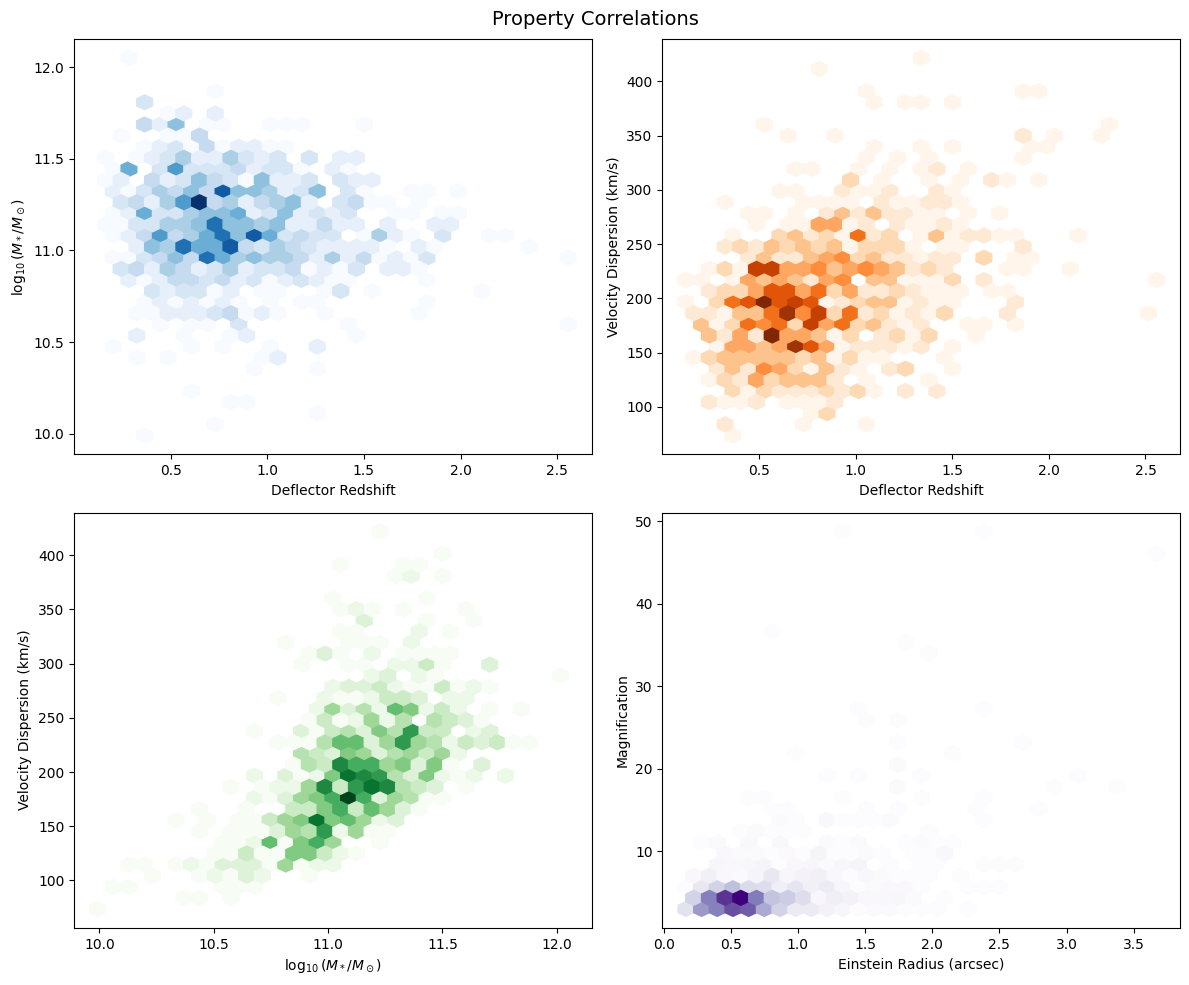

In [ ]:
# corner-style summary: key property correlations
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hexbin(z_deflector, np.log10(stellar_masses), gridsize=30, cmap='Blues', mincnt=1)
axes[0, 0].set_xlabel('Deflector Redshift')
axes[0, 0].set_ylabel(r'$\log_{10}(M_*/M_\odot)$')

axes[0, 1].hexbin(z_deflector, velocity_dispersions, gridsize=30, cmap='Oranges', mincnt=1)
axes[0, 1].set_xlabel('Deflector Redshift')
axes[0, 1].set_ylabel('Velocity Dispersion (km/s)')

axes[1, 0].hexbin(np.log10(stellar_masses), velocity_dispersions, gridsize=30, cmap='Greens', mincnt=1)
axes[1, 0].set_xlabel(r'$\log_{10}(M_*/M_\odot)$')
axes[1, 0].set_ylabel('Velocity Dispersion (km/s)')

axes[1, 1].hexbin(einstein_radii, magnifications, gridsize=30, cmap='Purples', mincnt=1)
axes[1, 1].set_xlabel('Einstein Radius (arcsec)')
axes[1, 1].set_ylabel('Magnification')

fig.suptitle('Property Correlations', fontsize=14)
plt.tight_layout()
plt.show()